# BayesWave Reconstruction Comparison

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from gwpy.timeseries import TimeSeries

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

/home/x-ctirapongpra/.local/lib/python3.9/site-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


## Load Real Data from Frame File

In [2]:
# Load the real gravitational wave signal from frame file
# Parameters from config.ini
frame_file = 'Frame.gwf'
channel = 'GW:HP_X'
segment_start_gps = 1000000000
trigtime_gps = 1000000003
seglen = 4.0
srate = 4096.0

# Read the frame file
data = TimeSeries.read(frame_file, channel=channel)
print(f"Full data duration: {data.duration.value:.2f} seconds")
print(f"Full data length: {len(data)} samples")
print(f"Sampling rate: {data.sample_rate.value} Hz")
print(f"GPS start time: {data.t0.value}")

# Extract the 4-second segment that BayesWave analyzed
segment_end_gps = trigtime_gps + seglen
hp_x_segment_ts = data.crop(trigtime_gps, segment_end_gps)

# Convert to numpy array
hp_x_segment = hp_x_segment_ts.value
time_segment = np.arange(len(hp_x_segment)) / srate

print(f"\nExtracted segment:")
print(f"  Length: {len(hp_x_segment)} samples")
print(f"  Duration: {len(hp_x_segment)/srate:.2f} seconds")
print(f"  Time range: {trigtime_gps} to {segment_end_gps} GPS")

Full data duration: 9.76 seconds
Full data length: 39996 samples
Sampling rate: 4096.0 Hz
GPS start time: 1000000000.0

Extracted segment:
  Length: 16384 samples
  Duration: 4.00 seconds
  Time range: 1000000003 to 1000000007.0 GPS


## Load BayesWave Templates

BayesWave produces 10 template samples from the posterior distribution.

In [3]:
def load_bayeswave_template(filepath):
    """Load a BayesWave template file, skipping the header."""
    with open(filepath, 'r') as f:
        # Skip header lines until we find the data separator
        for line in f:
            if line.strip() == '---------------':
                break
        # Skip the column header line
        next(f)
        # Read the data
        data = []
        for line in f:
            parts = line.strip().split()
            if len(parts) == 2:
                data.append([float(parts[0]), float(parts[1])])
    
    return np.array(data)

# Load all 11 templates (0-10)
templates = []
template_dir = Path('/home/x-ctirapongpra/scratch/onedetector/bayeswave_output_0/templates')

for i in range(11):
    template_file = template_dir / f'gw_all_colored_time_domain_template_H1_{i}.dat'
    if template_file.exists():
        template_data = load_bayeswave_template(template_file)
        templates.append(template_data)
        print(f"Template {i}: {len(template_data)} samples")

print(f"\nLoaded {len(templates)} templates")

Template 0: 16384 samples
Template 1: 16384 samples
Template 2: 16384 samples
Template 3: 16384 samples
Template 4: 16384 samples
Template 5: 16384 samples
Template 6: 16384 samples
Template 7: 16384 samples
Template 8: 16384 samples
Template 9: 16384 samples
Template 10: 16384 samples

Loaded 11 templates


## Extract BayesWave Analysis Segment

From the config file:
- segment-start = 1000000000 GPS time
- trigtime = 1000000003 GPS time
- seglen = 4.0 seconds

BayesWave analyzed a 4-second segment. We need to extract the corresponding segment from the real data.

Overplot all 10 BayesWave template reconstructions with the real gravitational wave signal.

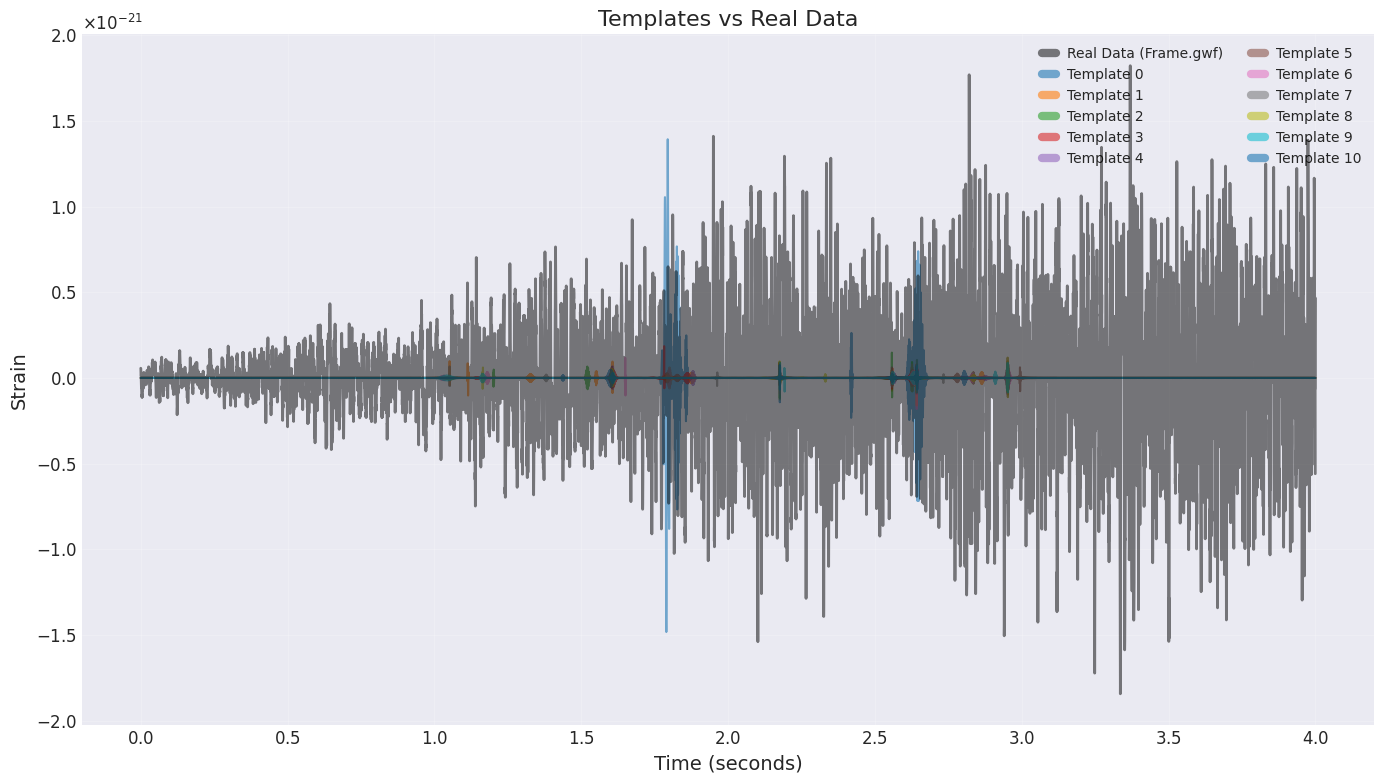

In [4]:
fig, ax = plt.subplots(figsize=(14, 8))

# Plot real data
ax.plot(time_segment, hp_x_segment, 'k-', linewidth=2, label='Real Data (Frame.gwf)', alpha=0.5, zorder=10)

# Plot all templates
for i, template in enumerate(templates):
    time_template = template[:, 0]
    strain_template = template[:, 1]
    ax.plot(time_template, strain_template, alpha=0.6, linewidth=1.5, label=f'Template {i}')

ax.set_xlabel('Time (seconds)', fontsize=14)
ax.set_ylabel('Strain', fontsize=14)
ax.set_title('Templates vs Real Data', fontsize=16)
ax.legend(loc='upper right', fontsize=10, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Frequency Domain Analysis

Plot the colored frequency domain data from BayesWave.

In [10]:
# Load the colored frequency domain data
freq_data_file = '/home/x-ctirapongpra/scratch/onedetector/bayeswave_output_0/data/whitened_frequency_domain_data_H1.dat'

frequency = []
real_part = []
imag_part = []

with open(freq_data_file, 'r') as f:
    # Skip header lines until we find the separator
    for line in f:
        if line.strip() == '---------------':
            next(f)  # Skip the "domainValue measuredValue" line
            break
    
    # Read the data
    for line in f:
        parts = line.strip().split()
        if len(parts) == 2:
            freq = float(parts[0])
            # Parse complex number (real,imag)
            complex_str = parts[1].strip('()')
            real, imag = map(float, complex_str.split(','))
            
            frequency.append(freq)
            real_part.append(real)
            imag_part.append(imag)

frequency = np.array(frequency)
real_part = np.array(real_part)
imag_part = np.array(imag_part)

# Calculate magnitude and phase
magnitude = np.sqrt(real_part**2 + imag_part**2)
phase = np.arctan2(imag_part, real_part)

print(f"Frequency range: {frequency[0]:.2f} to {frequency[-1]:.2f} Hz")
print(f"Number of frequency bins: {len(frequency)}")
print(f"Frequency resolution: {frequency[1] - frequency[0]:.4f} Hz")
print(f"\nMagnitude - Min: {magnitude.min():.6e}, Max: {magnitude.max():.6e}")
print(f"Non-zero frequency bins: {np.sum(magnitude > 0)} out of {len(magnitude)}")

Frequency range: 0.00 to 2048.00 Hz
Number of frequency bins: 8193
Frequency resolution: 0.2500 Hz

Magnitude - Min: 0.000000e+00, Max: 1.469213e+01
Non-zero frequency bins: 4016 out of 8193


IndexError: index 0 is out of bounds for axis 0 with size 0

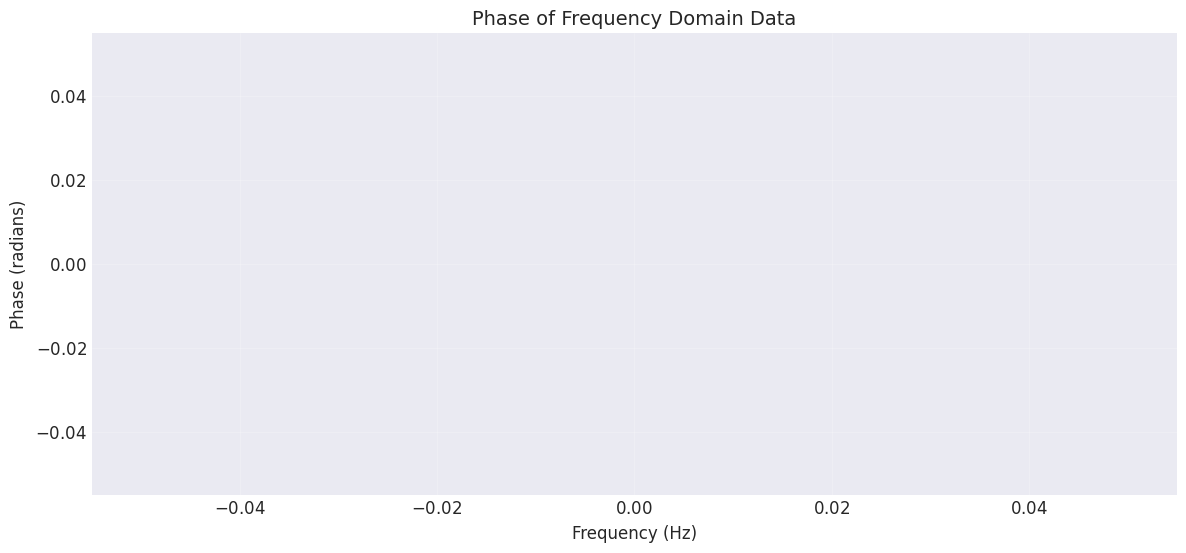

In [6]:
# Plot phase (only where magnitude is significant)
fig, ax = plt.subplots(figsize=(14, 6))

significant_mask = magnitude > 1e-10
ax.plot(frequency[significant_mask], phase[significant_mask], 'g-', linewidth=0.8)
ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('Phase (radians)', fontsize=12)
ax.set_title('Phase of Frequency Domain Data', fontsize=14)
ax.grid(True, alpha=0.3)
ax.set_xlim(frequency[significant_mask][0], frequency[significant_mask][-1])

plt.tight_layout()
plt.show()

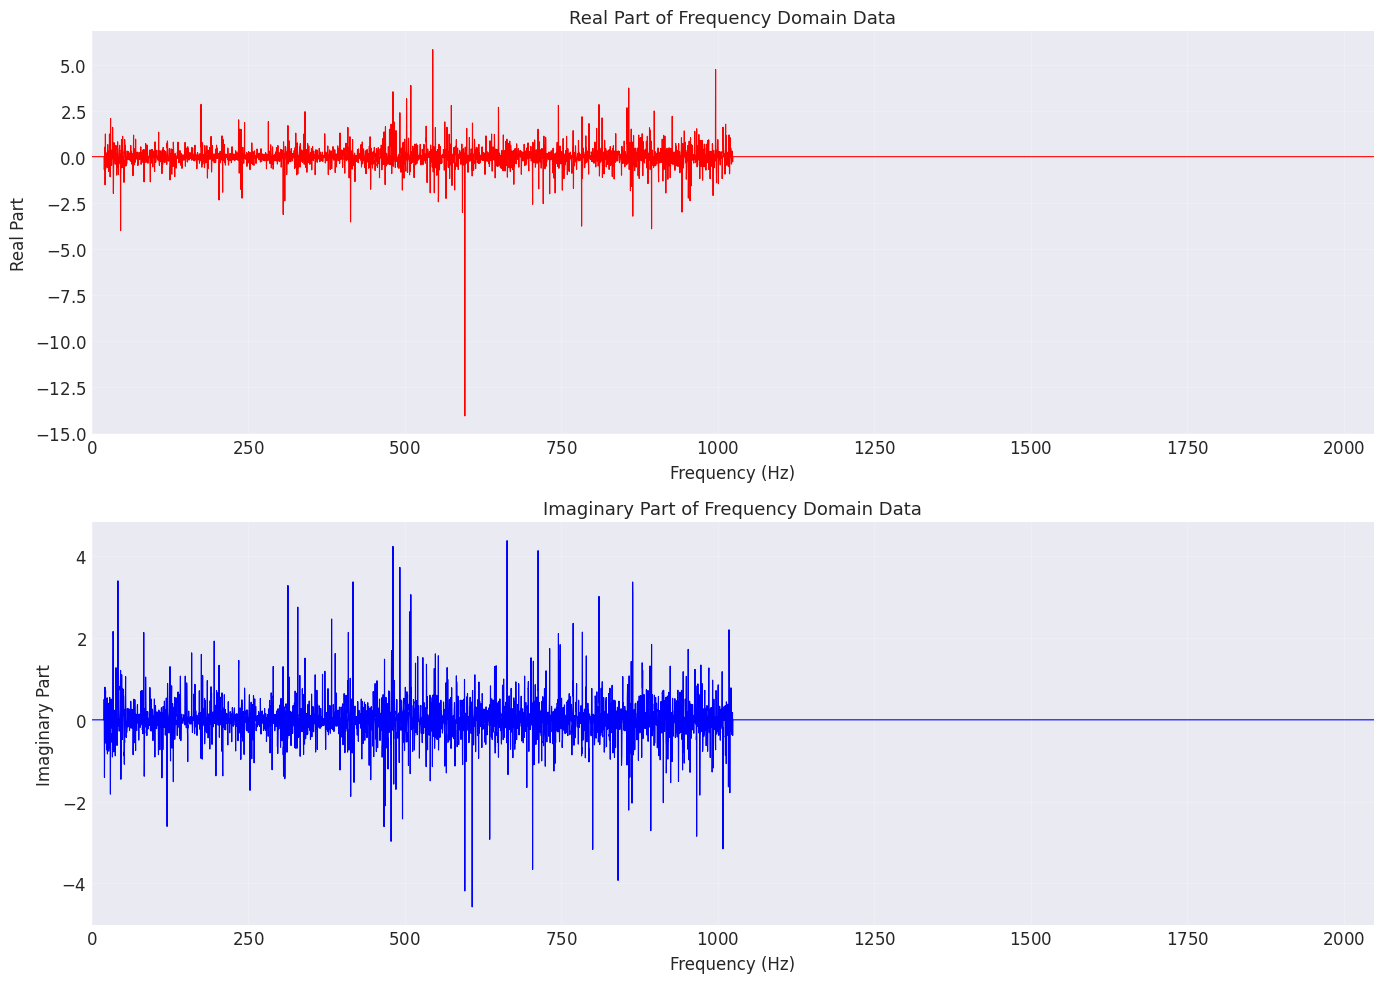

In [11]:
# Plot real and imaginary parts
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

ax1.plot(frequency, real_part, 'r-', linewidth=0.8)
ax1.set_xlabel('Frequency (Hz)', fontsize=12)
ax1.set_ylabel('Real Part', fontsize=12)
ax1.set_title('Real Part of Frequency Domain Data', fontsize=13)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(frequency[0], frequency[-1])

ax2.plot(frequency, imag_part, 'b-', linewidth=0.8)
ax2.set_xlabel('Frequency (Hz)', fontsize=12)
ax2.set_ylabel('Imaginary Part', fontsize=12)
ax2.set_title('Imaginary Part of Frequency Domain Data', fontsize=13)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(frequency[0], frequency[-1])

plt.tight_layout()
plt.show()

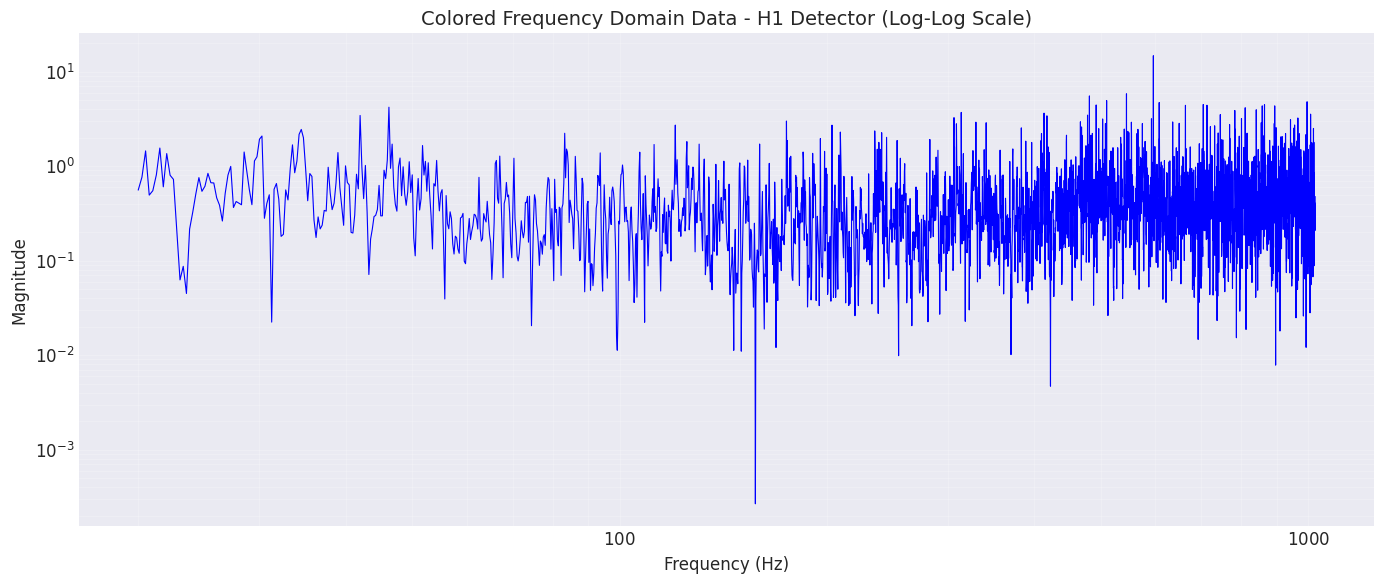

In [12]:
# Plot magnitude spectrum (log-log scale)
fig, ax = plt.subplots(figsize=(14, 6))

# Filter out zero values for log plot
nonzero_mask = magnitude > 0
ax.loglog(frequency[nonzero_mask], magnitude[nonzero_mask], 'b-', linewidth=0.8)
ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('Magnitude', fontsize=12)
ax.set_title('Colored Frequency Domain Data - H1 Detector (Log-Log Scale)', fontsize=14)
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

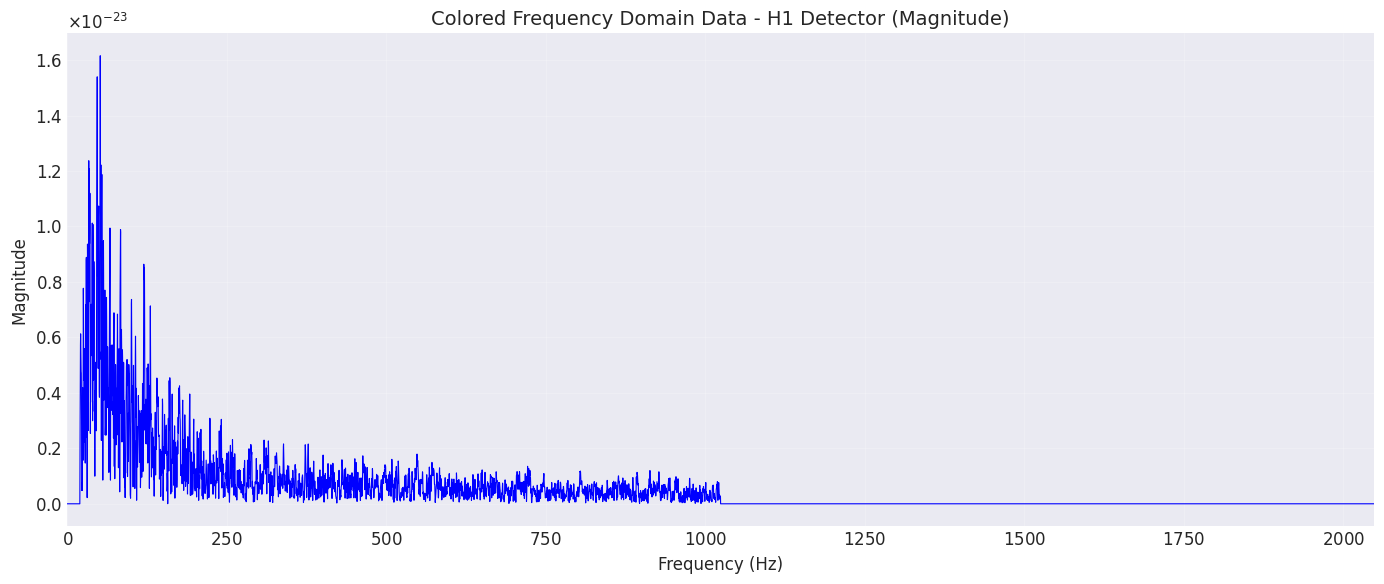

In [9]:
# Plot magnitude spectrum (linear scale)
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(frequency, magnitude, 'b-', linewidth=0.8)
ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('Magnitude', fontsize=12)
ax.set_title('Colored Frequency Domain Data - H1 Detector (Magnitude)', fontsize=14)
ax.grid(True, alpha=0.3)
ax.set_xlim(frequency[0], frequency[-1])

plt.tight_layout()
plt.show()